In [4]:
import pandas as pd
df=pd.read_csv(r"C:\Users\HARSHAVARDHAN\OneDrive\Desktop\TekWorks\phase2\27may\randomforest\data\Cardetailsv3.csv")

In [5]:
df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

In [6]:
df.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [10]:
# Mileage
df['mileage'] = df['mileage'].str.extract('(\d+\.?\d*)').astype(float)
df['mileage'] = df['mileage'].fillna(df['mileage'].median())

# Engine
df['engine'] = df['engine'].str.extract('(\d+)').astype(float)
df['engine'] = df['engine'].fillna(df['engine'].median())

# Max Power
df['max_power'] = df['max_power'].str.extract('(\d+\.?\d*)').astype(float)
df['max_power'] = df['max_power'].fillna(df['max_power'].median())

# Torque
df['torque'] = df['torque'].str.extract('(\d+)').astype(float)
df['torque'] = df['torque'].fillna(df['torque'].median())

# Seats
df['seats'] = df['seats'].fillna(df['seats'].mode()[0])

In [11]:
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
torque           0
seats            0
dtype: int64

In [12]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,190.0,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,250.0,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,12.0,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,22.0,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,11.0,5.0


In [14]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque',
       'seats'],
      dtype='object')

In [15]:
x=df.drop(columns=['selling_price'])
y=df['selling_price']

In [18]:
x.select_dtypes(include='object').columns

Index(['name', 'fuel', 'seller_type', 'transmission', 'owner'], dtype='object')

In [19]:
x = x.drop('name', axis=1)

In [20]:
x = pd.get_dummies(
    x,
    columns=['fuel', 'seller_type', 'transmission', 'owner'],
    drop_first=True
)

In [22]:
from sklearn.model_selection import train_test_split
xtr,xte,ytr,yte=train_test_split(x,y,test_size=0.2,random_state=42) 

In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(xtr, ytr)

best_rf = grid_search.best_estimator_

ypred = best_rf.predict(xte)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nR2 Score:", r2_score(yte, ypred))
print("MAE:", mean_absolute_error(yte, ypred))
print("RMSE:", np.sqrt(mean_squared_error(yte, ypred)))

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

R2 Score: 0.9696746025775962
MAE: 69408.10261563535
RMSE: 140988.74479714187


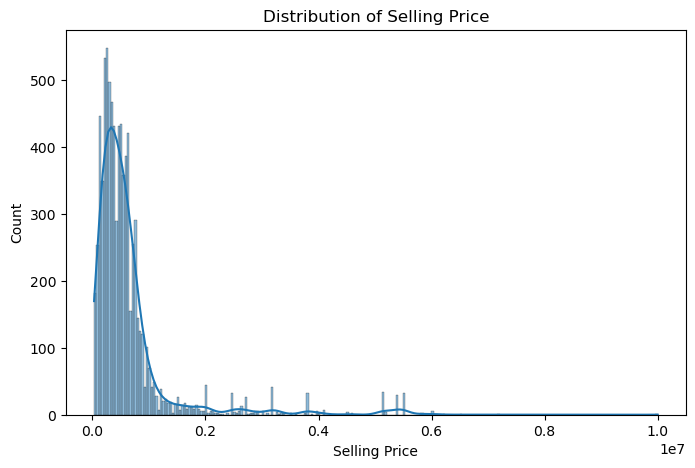

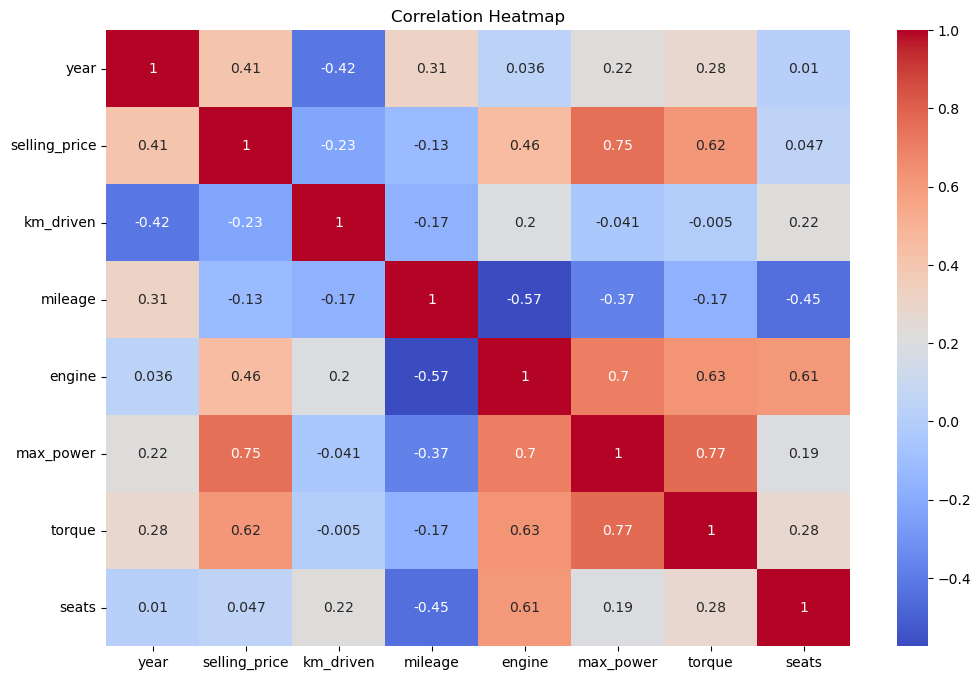

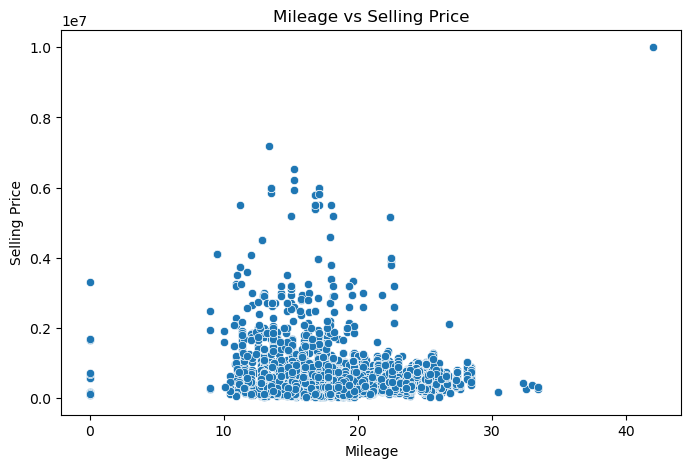

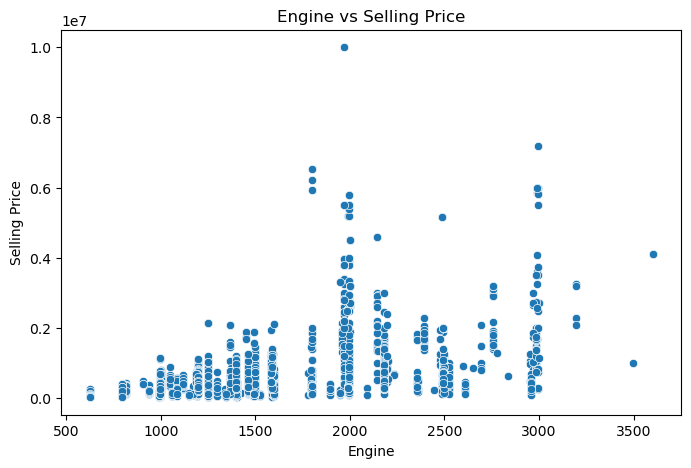

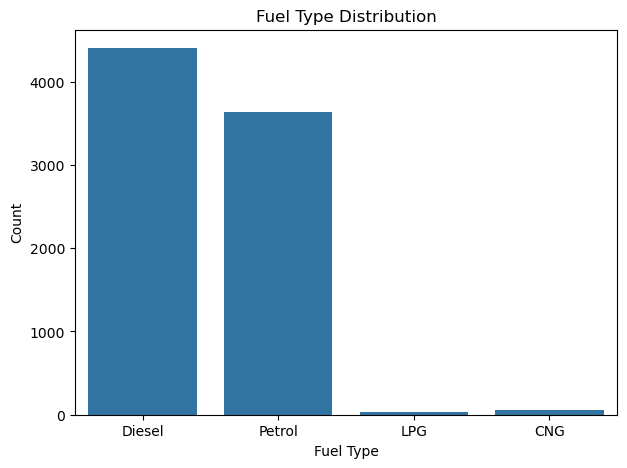

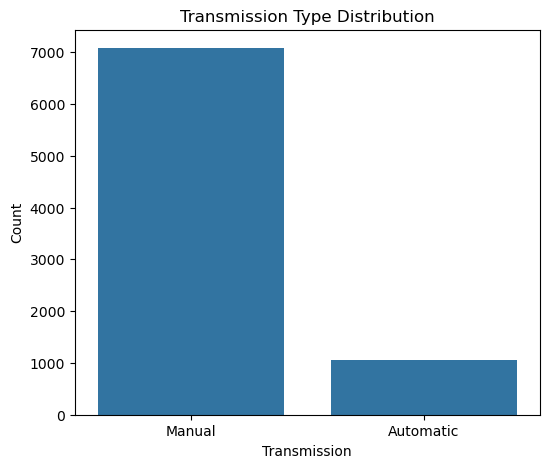

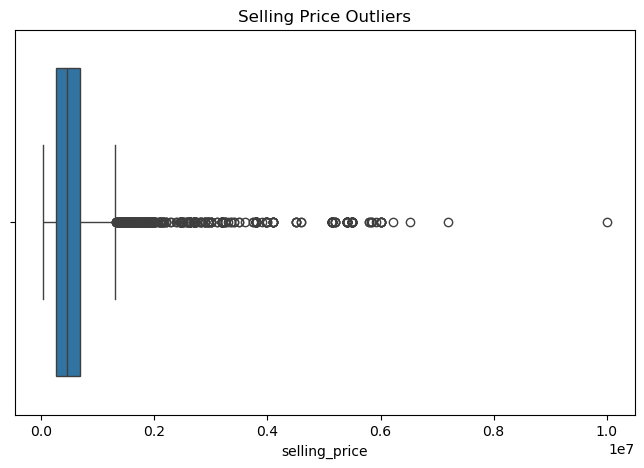

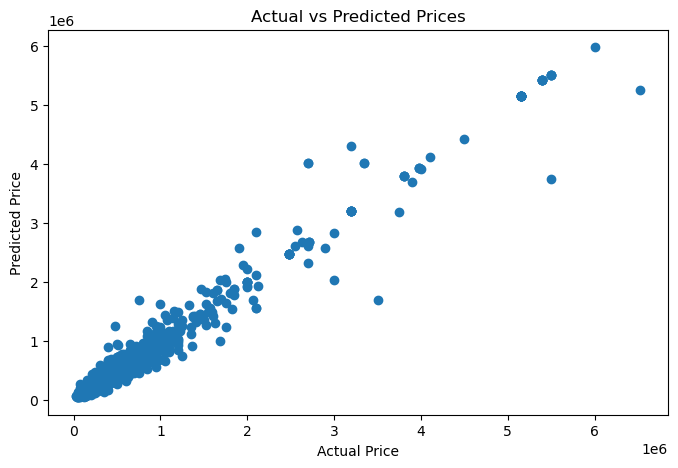

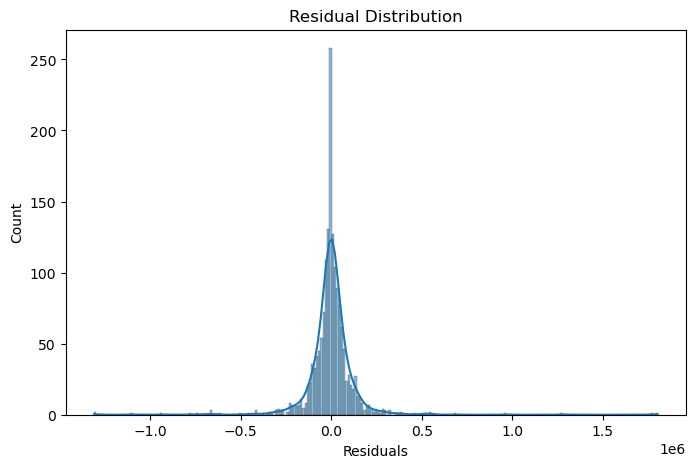

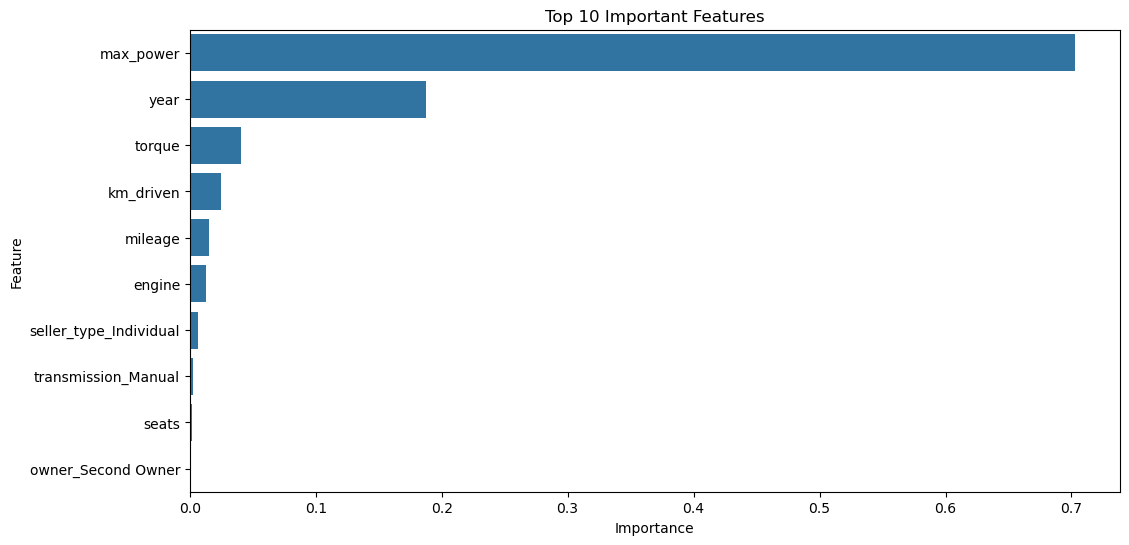

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Distribution of Selling Price
# =========================

plt.figure(figsize=(8,5))
sns.histplot(df['selling_price'], kde=True)
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Count")
plt.show()

# =========================
# Correlation Heatmap
# =========================

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# =========================
# Mileage vs Selling Price
# =========================

plt.figure(figsize=(8,5))
sns.scatterplot(x=df['mileage'], y=df['selling_price'])
plt.title("Mileage vs Selling Price")
plt.xlabel("Mileage")
plt.ylabel("Selling Price")
plt.show()

# =========================
# Engine vs Selling Price
# =========================

plt.figure(figsize=(8,5))
sns.scatterplot(x=df['engine'], y=df['selling_price'])
plt.title("Engine vs Selling Price")
plt.xlabel("Engine")
plt.ylabel("Selling Price")
plt.show()

# =========================
# Fuel Type Count Plot
# =========================

plt.figure(figsize=(7,5))
sns.countplot(x=df['fuel'])
plt.title("Fuel Type Distribution")
plt.xlabel("Fuel Type")
plt.ylabel("Count")
plt.show()

# =========================
# Transmission Type Count
# =========================

plt.figure(figsize=(6,5))
sns.countplot(x=df['transmission'])
plt.title("Transmission Type Distribution")
plt.xlabel("Transmission")
plt.ylabel("Count")
plt.show()

# =========================
# Boxplot for Outlier Detection
# =========================

plt.figure(figsize=(8,5))
sns.boxplot(x=df['selling_price'])
plt.title("Selling Price Outliers")
plt.show()

# =========================
# Actual vs Predicted Plot
# =========================

plt.figure(figsize=(8,5))
plt.scatter(yte, ypred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

# =========================
# Residual Plot
# =========================

residuals = yte - ypred

plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.show()

# =========================
# Feature Importance Plot
# =========================

importance = best_rf.feature_importances_
features = x.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(12,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df.head(10)
)

plt.title("Top 10 Important Features")
plt.show()

In [25]:
df['price_category'] = pd.cut(
    df['selling_price'],
    bins=[0, 500000, 1000000, 10000000],
    labels=['Low', 'Medium', 'High']
)

In [28]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque',
       'seats', 'price_category'],
      dtype='object')

In [41]:
y1=df['price_category']

In [42]:
df.dtypes

name                object
year                 int64
selling_price        int64
km_driven            int64
fuel                object
seller_type         object
transmission        object
owner               object
mileage            float64
engine             float64
max_power          float64
torque             float64
seats              float64
price_category    category
dtype: object

In [43]:
from sklearn.model_selection import train_test_split
xtr,xte,ytr,yte=train_test_split(x1,y1,test_size=0.2,random_state=42) 

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# =========================
# Random Forest Classifier
# =========================

rf = RandomForestClassifier(random_state=42)

# =========================
# Hyperparameter Grid
# =========================

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# =========================
# GridSearchCV
# =========================

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

# =========================
# Train Model
# =========================

grid_search.fit(xtr, ytr)

# =========================
# Best Model
# =========================

best_rf = grid_search.best_estimator_

# =========================
# Prediction
# =========================

ypred = best_rf.predict(xte)

# =========================
# Evaluation
# =========================

print("Best Parameters:")
print(grid_search.best_params_)

print("\nAccuracy Score:")
print(accuracy_score(yte, ypred))

print("\nClassification Report:")
print(classification_report(yte, ypred))

print("\nConfusion Matrix:")
print(confusion_matrix(yte, ypred))

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Accuracy Score:
0.8972939729397293

Classification Report:
              precision    recall  f1-score   support

        High       0.90      0.89      0.90       161
         Low       0.93      0.93      0.93       948
      Medium       0.84      0.84      0.84       517

    accuracy                           0.90      1626
   macro avg       0.89      0.89      0.89      1626
weighted avg       0.90      0.90      0.90      1626


Confusion Matrix:
[[144   0  17]
 [  1 880  67]
 [ 15  67 435]]
